# Imports

In [28]:
# Estándar
from collections import Counter
import warnings
import time

# Núcleo científico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
from scipy.stats import loguniform, uniform

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, precision_recall_curve, make_scorer
)

# Desbalanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Scikeras
from scikeras.wrappers import KerasClassifier

# Configuración global
warnings.filterwarnings("ignore")  # Silencia warnings innecesarios
from sklearn.decomposition import PCA


# Entrada de Datos

In [29]:
# Leemos el archivo CSV con los datos
df = pd.read_csv('email_phishing_data.csv', delimiter=',')

# Mostramos el número de filas (entradas) y columnas (variables)
nRow, nCol = df.shape
print(f'Nº entradas: {nRow} , Nº columnas: {nCol} ')

# Distribución de la variable objetivo 'label'
dist_label = (
    df['label']
    .value_counts()
    .rename_axis('Clase')
    .reset_index(name='Frecuencia')
)

display(dist_label)

Nº entradas: 524846 , Nº columnas: 9 


,Clase,Frecuencia
0,0,517897
1,1,6949


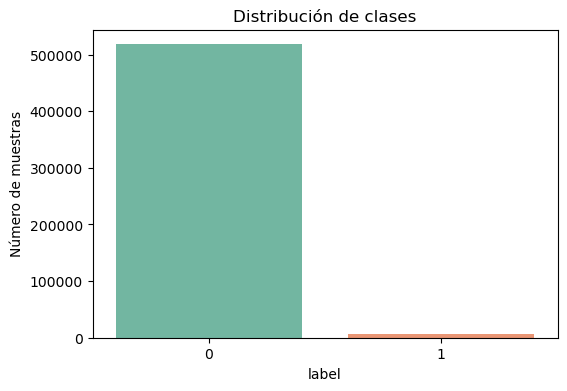

In [30]:
# Gráficamos la distribución
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette="Set2")
plt.title("Distribución de clases")
plt.ylabel("Número de muestras")
plt.show()


Después de leer los datos y ver la distribución de la clase objetivo, se puede ver un fuerte desbalanceo, dominando la clase no phishing por un gran margen. Lo cual, podría ser un problema para algunas pruebas, pero se tratará en el preprocesamiento.

Ahora procederemos a ver más características de estos datos y comentarlos

In [31]:
# Resumen estadístico de las variables
df.describe()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
count,5.248460e+05,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000
mean,2.762280e+02,123.012167,80.045465,0.895588,0.347767,2.114897,24.694731,0.245301,0.013240
std,3.335457e+03,201.626478,1023.330380,5.603001,1.774209,13.592682,311.312358,0.559320,0.114301
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.700000e+01,38.000000,12.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.200000e+02,79.000000,34.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000
75%,2.690000e+02,145.000000,79.000000,0.000000,0.000000,1.000000,22.000000,0.000000,0.000000
max,2.339682e+06,51251.000000,720411.000000,824.000000,524.000000,1150.000000,190104.000000,7.000000,1.000000


In [32]:
# Información general 
df.info()

# Resumen del mínimo, máximo y media de las variables
df.describe().T[['min','max','mean']]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   num_words            524846 non-null  int64
 1   num_unique_words     524846 non-null  int64
 2   num_stopwords        524846 non-null  int64
 3   num_links            524846 non-null  int64
 4   num_unique_domains   524846 non-null  int64
 5   num_email_addresses  524846 non-null  int64
 6   num_spelling_errors  524846 non-null  int64
 7   num_urgent_keywords  524846 non-null  int64
 8   label                524846 non-null  int64
dtypes: int64(9)
memory usage: 36.0 MB


,min,max,mean
num_words,0.0,2339682.0,276.228000
num_unique_words,0.0,51251.0,123.012167
num_stopwords,0.0,720411.0,80.045465
num_links,0.0,824.0,0.895588
num_unique_domains,0.0,524.0,0.347767
num_email_addresses,0.0,1150.0,2.114897
num_spelling_errors,0.0,190104.0,24.694731
num_urgent_keywords,0.0,7.0,0.245301
label,0.0,1.0,0.013240


In [33]:
# Comprobamos valores nulos en cada columna
df.isnull().sum()

num_words              0
num_unique_words       0
num_stopwords          0
num_links              0
num_unique_domains     0
num_email_addresses    0
num_spelling_errors    0
num_urgent_keywords    0
label                  0
dtype: int64

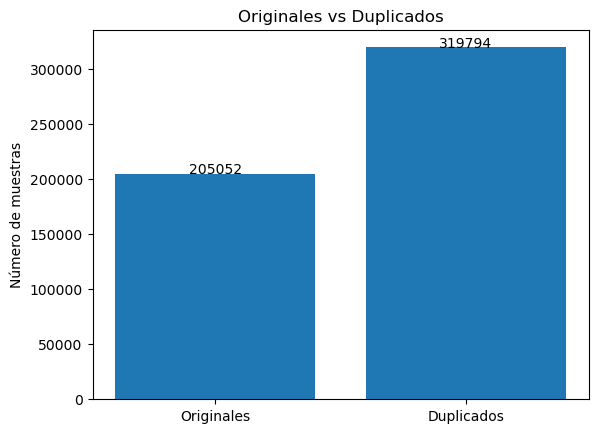

In [34]:
# Comprobamos el número de duplicados
duplicados = df.duplicated().sum()
total = len(df)
sin_duplicados = total - duplicados

# Preparamos los valores para graficar
valores = [sin_duplicados, duplicados]
categorias = ['Originales', 'Duplicados']

# Creamos un gráfico de barras comparando duplicados y originales
plt.bar(categorias, valores)
plt.title("Originales vs Duplicados")
plt.ylabel("Número de muestras")
plt.xlabel("")

# Mostrar valores encima de cada barra
for i, v in enumerate(valores):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()



Tras todo esto podemos ver:
- Todas las variables son de tipo **int64**, por lo que no será necesario realizar conversiones adicionales para el entrenamiento.  
- No se detectan **valores nulos** en el dataset.  
- Existe un **alto número de registros duplicados** (más del 50% del total), lo que podría afectar negativamente el rendimiento de varios modelos.  
- También hay muchas variables que tienen medias bajas en comparación con sus máximos, lo que indica una distribución irregular y la posible presencia de **outliers** (ej. `num_spelling_errors` con media ~25 y máximo >190.000). 

# Preprocesamiento 

Tras la exploración inicial de los datos, se procederá a eliminar las entradas duplicadas del dataset, normalización/estandarización de las variables y aplicación de una técnica de oversampling para tratar de equilibrar el número de clases phishing.

Número de duplicados después de limpiar: 0
Tamaño nuevo: (205052, 9)


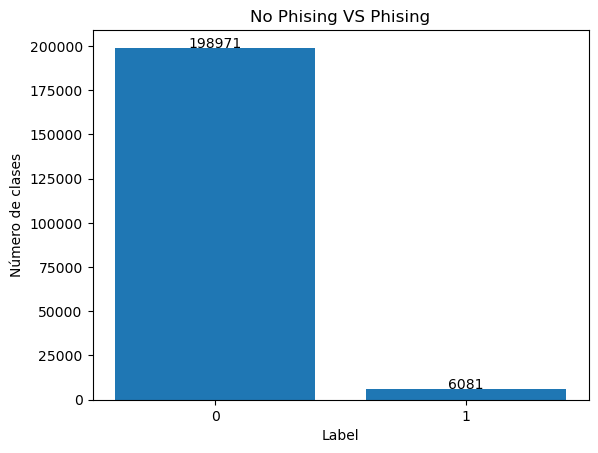

In [35]:
# Eliminación de duplicados
df_clean = df.drop_duplicates()

# Confirmamos que ya no queden duplicados
print("Número de duplicados después de limpiar:", df_clean.duplicated().sum())
print("Tamaño nuevo:", df_clean.shape)


# Visualización de la distribución de clases
categorias = df_clean['label'].value_counts().index.astype(str)   # ['0', '1']
valores = df_clean['label'].value_counts().values                 # cantidades

plt.bar(categorias, valores)
plt.title("No Phising VS Phising")
plt.ylabel("Número de clases")
plt.xlabel("Label")

# Mostrar el valor numérico encima de cada barra
for i, v in enumerate(valores):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()

A pesar de haber eliminado más de la mitad de las entradas por duplicados, el dataset resultante aún conserva un volumen considerable (cerca de 200.000 registros).  
Esta cantidad es suficiente para entrenar los modelos, y además se verá incrementada posteriormente mediante la técnica de **oversampling (SMOTE)** para equilibrar las clases.


Ahora veremos la distribución de las variables

## Tratamiento de outliers

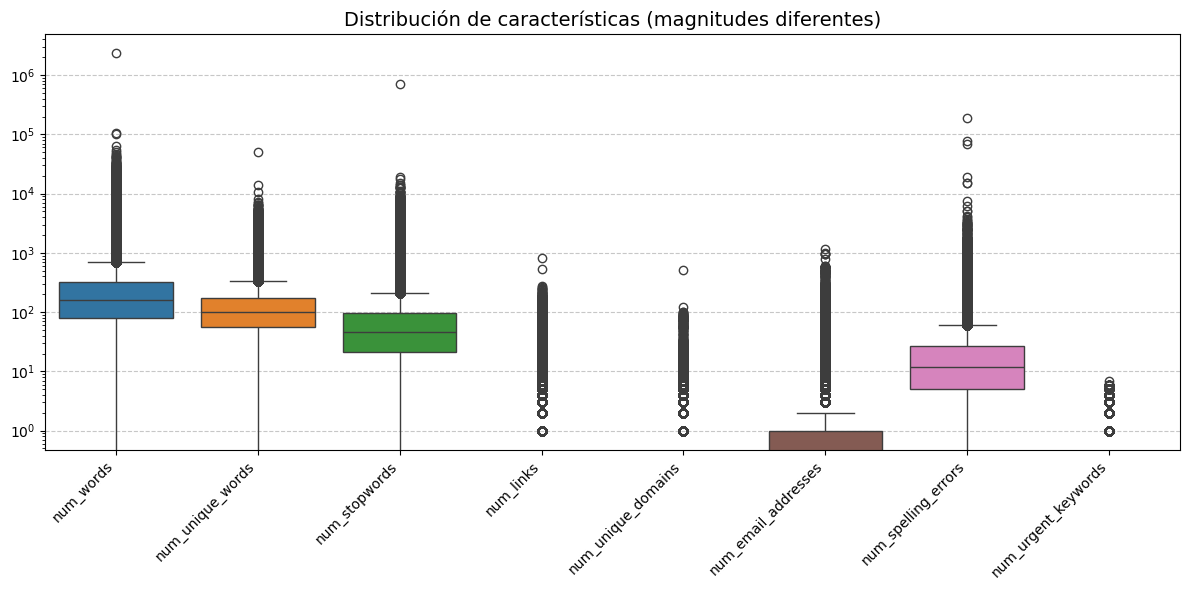

In [36]:
# Seleccionamos todas las columnas excepto la variable objetivo
features = [col for col in df_clean.columns if col != "label"]

# Gráfico de caja (boxplot) para todas las variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[features])

# Ajustes de estilo
plt.title("Distribución de características (magnitudes diferentes)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yscale("log")  # Usamos escala logarítmica para visualizar mejor las diferencias de magnitud
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [37]:
numeric_columns =['num_words', 'num_unique_words', 'num_stopwords', 'num_email_addresses', 'num_spelling_errors']

numeric_columns2 =['num_words', 'num_unique_words', 'num_stopwords', 'num_links',
       'num_unique_domains', 'num_email_addresses', 'num_spelling_errors',
       'num_urgent_keywords']

In [38]:
# Quitamos los outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Aplicamos la funcion a cada columna elegida
for col in numeric_columns:
    df_clean = remove_outliers_iqr(df_clean, col)

In [39]:
df_clean.describe()


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
count,138057.000000,138057.000000,138057.000000,138057.000000,138057.000000,138057.000000,138057.000000,138057.000000,138057.000000
mean,135.682964,84.321020,42.769523,0.340526,0.213861,0.314979,9.349059,0.186684,0.035304
std,99.330387,49.413869,34.393474,1.270601,0.602810,0.608975,8.162694,0.440016,0.184548
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,46.000000,17.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
50%,107.000000,74.000000,33.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000
75%,187.000000,114.000000,60.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
max,693.000000,279.000000,159.000000,38.000000,15.000000,2.000000,35.000000,5.000000,1.000000


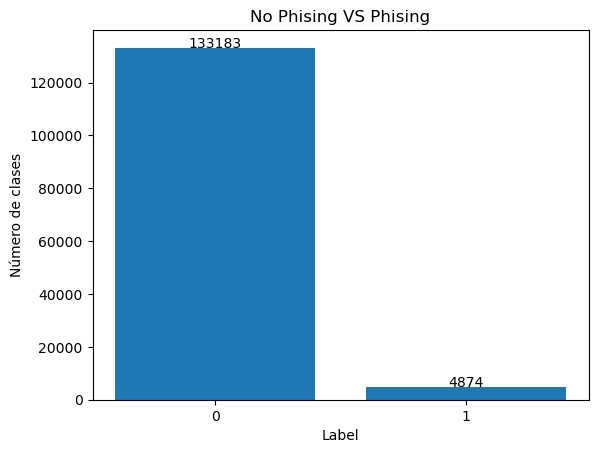

In [40]:
# Visualización de la distribución de clases
categorias = df_clean['label'].value_counts().index.astype(str)   # ['0', '1']
valores = df_clean['label'].value_counts().values                 # cantidades

plt.bar(categorias, valores)
plt.title("No Phising VS Phising")
plt.ylabel("Número de clases")
plt.xlabel("Label")

# Mostrar el valor numérico encima de cada barra
for i, v in enumerate(valores):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()

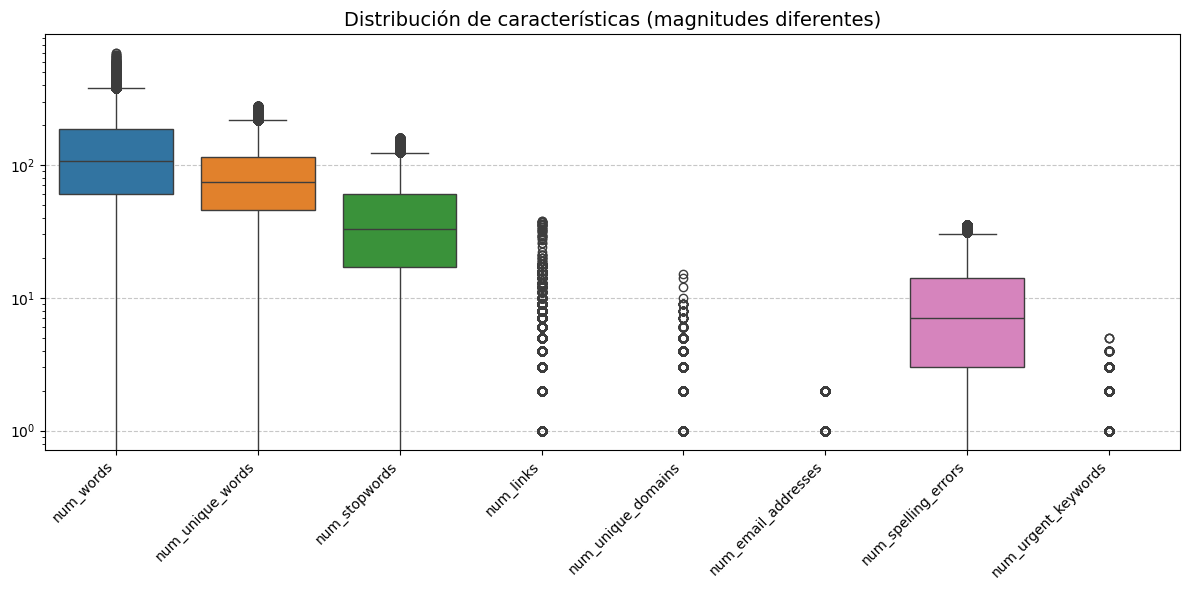

In [41]:
# Seleccionamos todas las columnas excepto la variable objetivo
features = [col for col in df_clean.columns if col != "label"]

# Gráfico de caja (boxplot) para todas las variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[features])

# Ajustes de estilo
plt.title("Distribución de características (magnitudes diferentes)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yscale("log")  # Usamos escala logarítmica para visualizar mejor las diferencias de magnitud
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


El boxplot evidencia las **diferencias de escala** entre las variables.
- Algunas variables, como `num_words`, `num_unique_words`, `num_stopwords`, `num_spelling_errors`, presentan valores significativamente mayores que el resto. 
- Otras, como `num_links`, `num_unique_domains` o `num_email_addresses`, tienen valores bastante pequeños en comparación a los anteriores.  
- Tras la eliminación de outliers en las variables de mayor magnitud, todavía se observan valores extremos, pero con una dispersión más controlada

Con esta información podemos ver qué variables necesitan mayor escalado que otras y se tendrán en cuenta para el escalado.



In [42]:
# Transformación y escalado de variables

# Definimos dos grupos de variables:
#  - features_log: variables con distribuciones más grandes y con valores extremos (colas largas)
#  - features_only_scale: variables con escalas más pequeñas pero que requieren estandarización
features_log = ['num_words','num_unique_words','num_stopwords','num_spelling_errors']
features_only_scale = ['num_links','num_unique_domains','num_email_addresses','num_urgent_keywords']
features_all = features_log + features_only_scale

# Creamos una copia del conjunto de características
df_clean_log = df_clean.copy()


# Aplicamos la transformación logarítmica a las variables de mayor magnitud
for col in features_log:
    df_clean_log[col] = np.log1p(df_clean_log[col])

# X / y para MODELADO
X = df_clean_log[features_all].copy()
y = df_clean_log["label"].astype(int)

# Aplicamos un escalado estándar (media 0, desviación estándar 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos el resultado a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features_all)





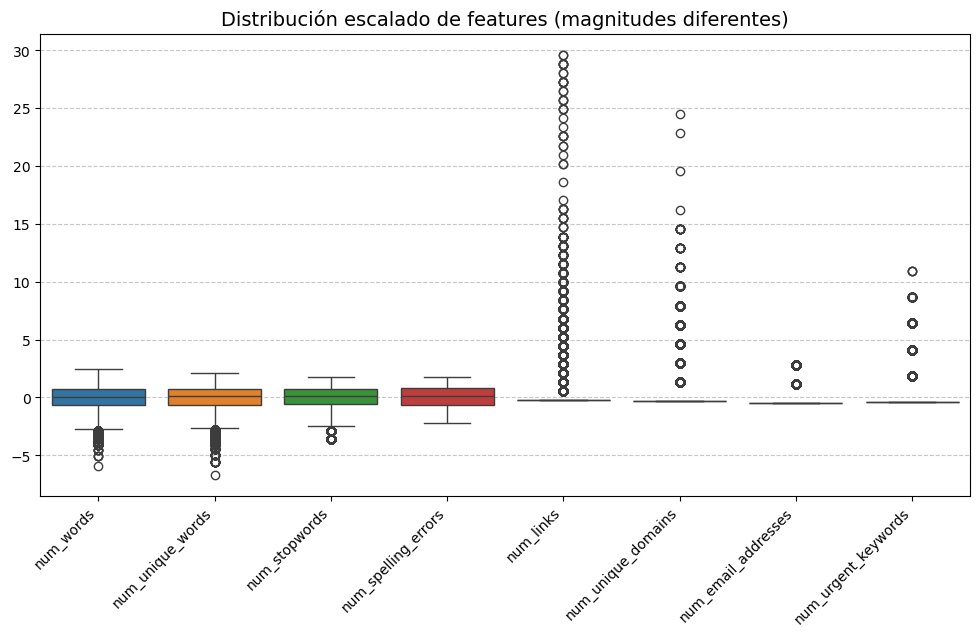

In [43]:
# Boxplot de las variables después del escalado estándar
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_scaled_df)

# Ajustes visuales
plt.title("Distribución escalado de features (magnitudes diferentes)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()


In [44]:
# Resumen estadístico después del escalado
X_scaled_df.describe()

,num_words,num_unique_words,num_stopwords,num_spelling_errors,num_links,num_unique_domains,num_email_addresses,num_urgent_keywords
count,1.380570e+05,1.380570e+05,1.380570e+05,1.380570e+05,1.380570e+05,1.380570e+05,1.380570e+05,1.380570e+05
mean,1.269391e-15,-9.041783e-16,-3.829171e-17,5.912569e-16,6.587820e-17,-4.611474e-17,8.893557e-17,4.107094e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-5.931538e+00,-6.670752e+00,-3.636006e+00,-2.237475e+00,-2.680049e-01,-3.547747e-01,-5.172293e-01,-4.242673e-01
25%,-6.790752e-01,-6.477366e-01,-5.643894e-01,-6.811804e-01,-2.680049e-01,-3.547747e-01,-5.172293e-01,-4.242673e-01
50%,5.082023e-02,8.335198e-02,1.114800e-01,9.696667e-02,-2.680049e-01,-3.547747e-01,-5.172293e-01,-4.242673e-01
75%,7.590630e-01,7.520281e-01,7.326461e-01,8.026609e-01,-2.680049e-01,-3.547747e-01,-5.172293e-01,-4.242673e-01
max,2.427777e+00,2.144085e+00,1.757414e+00,1.785487e+00,2.963922e+01,2.452878e+01,2.766989e+00,1.093899e+01


In [45]:
# Resumen del mínimo, máximo y media
X_scaled_df.describe().T[['min','max','mean']]

,min,max,mean
num_words,-5.931538,2.427777,1.269391e-15
num_unique_words,-6.670752,2.144085,-9.041783e-16
num_stopwords,-3.636006,1.757414,-3.829171e-17
num_spelling_errors,-2.237475,1.785487,5.912569e-16
num_links,-0.268005,29.639219,6.587820e-17
num_unique_domains,-0.354775,24.528783,-4.611474e-17
num_email_addresses,-0.517229,2.766989,8.893557e-17
num_urgent_keywords,-0.424267,10.938994,4.107094e-17


Después de aplicar la transformación logarítmica a las variables con mayor magnitud y el escalado estándar al conjunto de características, todas las variables presentan **medias** cercanas a **0** y **desviaciones estándar** próximas a **1**, lo que confirma que el proceso de normalización fue exitoso.

En el boxplot, se observa que las distribuciones de las variables previamente más grandes (num_words, num_unique_words, num_stopwords, num_spelling_errors) ahora están más compactas y centradas, lo que indica que se ha conseguido reducir la asimetría y las colas largas.

Por otro lado, las variables con valores pequeños y esparsos (num_links, num_unique_domains, num_email_addresses, num_urgent_keywords) mantienen valores atípicos visibles, pero pequeños y que son información clave de estas variables al tener números tan pequeños.

En conjunto, el siguiente paso sería hacer un PCA para ver la aportación de cada variable y el oversampling.

## PCA

In [46]:
# Ajustar PCA  
pca = PCA()
pca.fit(X_scaled_df)

# Matriz de cargas (importancia de variables)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X_scaled_df.columns))],
    index=X_scaled_df.columns
)

print("Cargas (contribución por variable y PC):")
display(loadings)


Cargas (contribución por variable y PC):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
num_words,0.516225,-0.167642,0.004020,-0.084217,-0.091626,-0.019438,-0.323479,0.764779
num_unique_words,0.512155,-0.165429,0.008630,-0.078008,-0.132498,0.031673,-0.535009,-0.631964
num_stopwords,0.473619,-0.211465,-0.079716,-0.127343,-0.364706,0.000106,0.751152,-0.105627
num_spelling_errors,0.364120,-0.016621,0.269861,0.017130,0.864358,0.002853,0.208939,-0.056952
num_links,0.193499,0.642073,-0.158331,-0.167114,-0.016338,-0.704511,0.002068,-0.026427
num_unique_domains,0.182142,0.656055,-0.087463,-0.164478,-0.038478,0.706658,0.017256,0.023860
num_email_addresses,0.125707,0.237327,0.690043,0.607925,-0.282009,-0.042121,0.027975,0.007464
num_urgent_keywords,0.167006,0.023366,-0.641757,0.738756,0.112459,0.033706,0.012553,-0.003242


El análisis de las cargas del PCA muestra que todas las variables presentan una contribución relevante en al menos uno de los componentes principales.

Las variables relacionadas con el contenido del texto (num_words, num_unique_words, num_stopwords, num_spelling_errors) tienen pesos elevados en los primeros componentes, asociados a la estructura y complejidad del mensaje.

Las variables relacionadas con comportamiento típico de spam, como num_links y num_unique_domains, tienen una contribución muy marcada en el segundo componente.

Variables vinculadas a tácticas de phishing, como num_email_addresses y num_urgent_keywords, destacan en los componentes siguientes.

Esto confirma que todas las características aportan información relevante en diferentes dimensiones de los datos, por lo que no se procede a eliminar ninguna variable.

# Entrenamiento de modelos

## Experimento 1

In [22]:
tf.random.set_seed(42); np.random.seed(42)

In [23]:
input_dim = X.shape[1]

In [125]:
# === Definir constructor del modelo ===
def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo  ===
mlp1 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp1 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp1),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP_CV1 = cross_validate(
    pipe_mlp1, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP_CV1 = time.time() - start

In [126]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP_CV1[f"test_{metric}"].mean()
    std = scores_MLP_CV1[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP_CV1:.2f}s  |  ~{train_time_MLP_CV1/10:.2f}s por fold")


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9602 ± 0.0013
precision_macro: 0.6778 ± 0.0134
   recall_macro: 0.5973 ± 0.0075
       f1_macro: 0.6240 ± 0.0086
       recall_1: 0.2068 ± 0.0153
    precision_1: 0.3842 ± 0.0265
           f1_1: 0.2685 ± 0.0168
       recall_0: 0.9878 ± 0.0013
    precision_0: 0.9715 ± 0.0005
           f1_0: 0.9796 ± 0.0007

Tiempo total CV: 776.03s  |  ~77.60s por fold


## Experimento 2

In [24]:
# === Definir constructor del modelo ===
def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo ===
mlp2 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp2),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP2 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP2 = time.time() - start

In [26]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP2[f"test_{metric}"].mean()
    std = scores_MLP2[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP2:.2f}s  |  ~{train_time_MLP2/10:.2f}s por fold")


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9566 ± 0.0030
precision_macro: 0.6534 ± 0.0229
   recall_macro: 0.6029 ± 0.0097
       f1_macro: 0.6218 ± 0.0114
       recall_1: 0.2224 ± 0.0200
    precision_1: 0.3350 ± 0.0455
           f1_1: 0.2660 ± 0.0219
       recall_0: 0.9835 ± 0.0033
    precision_0: 0.9719 ± 0.0007
           f1_0: 0.9776 ± 0.0016

Tiempo total CV: 1523.15s  |  ~152.32s por fold


## Experimento 3

In [65]:
# === Definir constructor del modelo ===
def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(512, activation="swish", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(256, activation="swish", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(128, activation="swish", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation="swish", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
])
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4, clipnorm=1.0),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo  === 
mlp3 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=150,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=4, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp3),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
 
scores_MLP3 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP3 = time.time() - start

In [66]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP3[f"test_{metric}"].mean()
    std = scores_MLP3[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP3:.2f}s  |  ~{train_time_MLP3/10:.2f}s por fold")


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9593 ± 0.0015
precision_macro: 0.6777 ± 0.0149
   recall_macro: 0.6152 ± 0.0078
     recall_pos: 0.2450 ± 0.0149
  precision_pos: 0.3827 ± 0.0293
         f1_pos: 0.2986 ± 0.0190
       f1_macro: 0.6388 ± 0.0099
        roc_auc: nan ± nan
average_precision: nan ± nan

Tiempo total CV: 7643.07s  |  ~764.31s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[131090   2093]
 [  3645   1229]]


## Experimento 4

In [71]:
# === Definir constructor del modelo ===
def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="swish"),  
        layers.Dropout(0.2),
        layers.Dense(128, activation="swish"),  
        layers.Dropout(0.2),
        layers.Dense(64,  activation="swish"),  
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo===
mlp4  = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=4, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline  ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp4),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
 
scores_MLP4 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP4 = time.time() - start

In [72]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP4[f"test_{metric}"].mean()
    std = scores_MLP4[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP4:.2f}s  |  ~{train_time_MLP4/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9602 ± 0.0012
precision_macro: 0.6778 ± 0.0142
   recall_macro: 0.5993 ± 0.0101
     recall_pos: 0.2109 ± 0.0205
  precision_pos: 0.3839 ± 0.0280
         f1_pos: 0.2719 ± 0.0219
       f1_macro: 0.6257 ± 0.0111
        roc_auc: nan ± nan
average_precision: nan ± nan

Tiempo total CV: 2996.51s  |  ~299.65s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[131414   1769]
 [  3903    971]]


## Experimento 5

In [75]:
# === Definir constructor del modelo ===


def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp5 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=256,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp5),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP5 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP5 = time.time() - start

In [76]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP5[f"test_{metric}"].mean()
    std = scores_MLP5[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP5:.2f}s  |  ~{train_time_MLP5/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9579 ± 0.0012
precision_macro: 0.6667 ± 0.0112
   recall_macro: 0.6153 ± 0.0089
     recall_pos: 0.2466 ± 0.0181
  precision_pos: 0.3606 ± 0.0220
         f1_pos: 0.2926 ± 0.0179
       f1_macro: 0.6355 ± 0.0092

Tiempo total CV: 2492.21s  |  ~249.22s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[131054   2129]
 [  3656   1218]]


## Experimento 6

In [77]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp6 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=256,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp6),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP6 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP6 = time.time() - start

In [78]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP6[f"test_{metric}"].mean()
    std = scores_MLP6[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP6:.2f}s  |  ~{train_time_MLP6/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9595 ± 0.0018
precision_macro: 0.6786 ± 0.0170
   recall_macro: 0.6144 ± 0.0079
     recall_pos: 0.2431 ± 0.0154
  precision_pos: 0.3846 ± 0.0336
         f1_pos: 0.2976 ± 0.0195
       f1_macro: 0.6384 ± 0.0101

Tiempo total CV: 2306.30s  |  ~230.63s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[131258   1925]
 [  3676   1198]]


## Experimento 7

In [79]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp7 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline: StandardScaler -> SMOTE (solo en train) -> MLP ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp7),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP7 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP7 = time.time() - start

In [80]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP7[f"test_{metric}"].mean()
    std = scores_MLP7[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP7:.2f}s  |  ~{train_time_MLP7/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9566 ± 0.0024
precision_macro: 0.6567 ± 0.0151
   recall_macro: 0.6115 ± 0.0128
     recall_pos: 0.2403 ± 0.0273
  precision_pos: 0.3410 ± 0.0302
         f1_pos: 0.2805 ± 0.0220
       f1_macro: 0.6291 ± 0.0111

Tiempo total CV: 1512.08s  |  ~151.21s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[130893   2290]
 [  3709   1165]]


## Experimento 8

In [81]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32,  activation="relu"),   # <- capa nueva
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp8 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp8),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP8 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP8 = time.time() - start

In [82]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP8[f"test_{metric}"].mean()
    std = scores_MLP8[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP8:.2f}s  |  ~{train_time_MLP8/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9572 ± 0.0021
precision_macro: 0.6620 ± 0.0149
   recall_macro: 0.6150 ± 0.0103
     recall_pos: 0.2468 ± 0.0214
  precision_pos: 0.3513 ± 0.0296
         f1_pos: 0.2892 ± 0.0200
       f1_macro: 0.6335 ± 0.0102

Tiempo total CV: 1845.64s  |  ~184.56s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[131000   2183]
 [  3691   1183]]


## Experimento 9

In [83]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp9 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp9),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP9 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP9 = time.time() - start

In [84]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP9[f"test_{metric}"].mean()
    std = scores_MLP9[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP9:.2f}s  |  ~{train_time_MLP9/10:.2f}s por fold")



=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9561 ± 0.0024
precision_macro: 0.6570 ± 0.0159
   recall_macro: 0.6193 ± 0.0113
     recall_pos: 0.2569 ± 0.0239
  precision_pos: 0.3410 ± 0.0316
         f1_pos: 0.2921 ± 0.0207
       f1_macro: 0.6347 ± 0.0106

Tiempo total CV: 1806.65s  |  ~180.66s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[130814   2369]
 [  3638   1236]]


## Experimento 10

In [85]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32,  activation="relu"),  
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp10 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp10),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP10 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP10 = time.time() - start

In [86]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP10[f"test_{metric}"].mean()
    std = scores_MLP10[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP10:.2f}s  |  ~{train_time_MLP10/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9555 ± 0.0030
precision_macro: 0.6566 ± 0.0162
   recall_macro: 0.6233 ± 0.0160
     recall_pos: 0.2659 ± 0.0354
  precision_pos: 0.3398 ± 0.0328
         f1_pos: 0.2958 ± 0.0202
       f1_macro: 0.6364 ± 0.0099

Tiempo total CV: 3282.57s  |  ~328.26s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[130478   2705]
 [  3562   1312]]


## Experimento 11

In [123]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32,  activation="relu"),  
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo=== 
mlp11 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline  ===
pipe_mlp11 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp11),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados   ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP11 = cross_validate(
    pipe_mlp11, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP11 = time.time() - start

In [124]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP11[f"test_{metric}"].mean()
    std = scores_MLP11[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP11:.2f}s  |  ~{train_time_MLP11/10:.2f}s por fold")



=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9519 ± 0.0021
precision_macro: 0.6452 ± 0.0089
   recall_macro: 0.6419 ± 0.0163
       f1_macro: 0.6430 ± 0.0111
       recall_1: 0.3084 ± 0.0348
    precision_1: 0.3157 ± 0.0174
           f1_1: 0.3109 ± 0.0223
       recall_0: 0.9755 ± 0.0031
    precision_0: 0.9747 ± 0.0012
           f1_0: 0.9751 ± 0.0012

Tiempo total CV: 10427.21s  |  ~1042.72s por fold


## Experimento 12

In [89]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),

    
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp12 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp12),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP12 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP12 = time.time() - start

In [90]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP12[f"test_{metric}"].mean()
    std = scores_MLP12[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP12:.2f}s  |  ~{train_time_MLP12/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9566 ± 0.0018
precision_macro: 0.6629 ± 0.0126
   recall_macro: 0.6261 ± 0.0090
     recall_pos: 0.2704 ± 0.0185
  precision_pos: 0.3523 ± 0.0249
         f1_pos: 0.3055 ± 0.0171
       f1_macro: 0.6415 ± 0.0088

Tiempo total CV: 3609.87s  |  ~360.99s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[130835   2348]
 [  3604   1270]]


## Experimento 13

In [91]:
# === Definir constructor del modelo ===

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
    
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
    
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
    
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
    
        layers.Dense(32,  activation="relu"),   
        layers.BatchNormalization(),
        layers.Dropout(0.2),
    
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp13 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp13),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP13 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP13 = time.time() - start

In [92]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP13[f"test_{metric}"].mean()
    std = scores_MLP13[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP13:.2f}s  |  ~{train_time_MLP13/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9556 ± 0.0022
precision_macro: 0.6600 ± 0.0142
   recall_macro: 0.6324 ± 0.0135
     recall_pos: 0.2846 ± 0.0280
  precision_pos: 0.3461 ± 0.0281
         f1_pos: 0.3115 ± 0.0235
       f1_macro: 0.6443 ± 0.0120

Tiempo total CV: 5326.87s  |  ~532.69s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[130434   2749]
 [  3469   1405]]


## Experimento 14

In [93]:
# === Definir constructor del modelo ===
def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
    
        layers.Dense(256, activation="swish"),
        layers.Dropout(0.2),
    
        layers.Dense(128, activation="swish"),
        layers.Dropout(0.2),
    
        layers.Dense(64, activation="swish"),
        layers.Dropout(0.2),
    
        layers.Dense(32,  activation="swish"),  
        layers.Dropout(0.2),
    
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo ===
mlp14 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp14),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP14 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP14 = time.time() - start

In [94]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP14[f"test_{metric}"].mean()
    std = scores_MLP14[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP14:.2f}s  |  ~{train_time_MLP14/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9609 ± 0.0020
precision_macro: 0.6848 ± 0.0248
   recall_macro: 0.5956 ± 0.0130
     recall_pos: 0.2025 ± 0.0261
  precision_pos: 0.3983 ± 0.0491
         f1_pos: 0.2677 ± 0.0303
       f1_macro: 0.6238 ± 0.0155

Tiempo total CV: 3870.53s  |  ~387.05s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[131623   1560]
 [  3908    966]]


In [95]:


probs_oof = cross_val_predict(
    pipe_mlp, X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]  # prob de clase 1 (phishing)

thresholds = np.linspace(0.0, 1.0, 21)

results = []
for thr in thresholds:
    y_pred = (probs_oof >= thr).astype(int)

    rec = recall_score(y, y_pred, pos_label=1)
    pre = precision_score(y, y_pred, pos_label=1, zero_division=0)
    f1  = f1_score(y, y_pred, pos_label=1)
    acc = accuracy_score(y, y_pred)

    results.append([thr, rec, pre, f1, acc])

print("\n=== Resultados por umbral ===")
print("thr   recall   precision   f1     accuracy")
for r in results:
    print(f"{r[0]:.2f}  {r[1]:.4f}    {r[2]:.4f}     {r[3]:.4f}  {r[4]:.4f}")



=== Resultados por umbral ===
thr   recall   precision   f1     accuracy
0.00  1.0000    0.0353     0.0682  0.0353
0.05  0.9598    0.0498     0.0948  0.3526
0.10  0.8586    0.0689     0.1276  0.5855
0.15  0.7577    0.0898     0.1606  0.7204
0.20  0.6654    0.1129     0.1930  0.8036
0.25  0.5720    0.1369     0.2209  0.8576
0.30  0.4666    0.1609     0.2393  0.8953
0.35  0.3781    0.1967     0.2588  0.9235
0.40  0.3032    0.2482     0.2729  0.9430
0.45  0.2400    0.3066     0.2693  0.9540
0.50  0.2000    0.3710     0.2599  0.9598
0.55  0.1732    0.4485     0.2499  0.9633
0.60  0.1510    0.5257     0.2346  0.9652
0.65  0.1319    0.5987     0.2162  0.9662
0.70  0.1155    0.6671     0.1969  0.9667
0.75  0.1005    0.7481     0.1772  0.9670
0.80  0.0837    0.8095     0.1517  0.9670
0.85  0.0706    0.8557     0.1304  0.9668
0.90  0.0568    0.8994     0.1069  0.9665
0.95  0.0375    0.9385     0.0722  0.9659
1.00  0.0000    0.0000     0.0000  0.9647


## Experimento 15

In [96]:
# === Definir constructor del modelo ===
tf.random.set_seed(7); np.random.seed(7)


def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.2),
    
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
    
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
    
        layers.Dense(32,  activation="relu"),  
        layers.Dropout(0.2),
    
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp15 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline  ===
pipe_mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp15),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP15 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP15 = time.time() - start

In [97]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP15[f"test_{metric}"].mean()
    std = scores_MLP15[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP15:.2f}s  |  ~{train_time_MLP15/10:.2f}s por fold")
 


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9511 ± 0.0017
precision_macro: 0.6421 ± 0.0081
   recall_macro: 0.6428 ± 0.0118
     recall_pos: 0.3110 ± 0.0248
  precision_pos: 0.3094 ± 0.0159
         f1_pos: 0.3097 ± 0.0174
       f1_macro: 0.6422 ± 0.0088

Tiempo total CV: 7033.15s  |  ~703.31s por fold

=== Matriz de confusión (CV out-of-fold) ===
[[129753   3430]
 [  3325   1549]]


## Experimento 16

In [101]:
# === Definir constructor del modelo ===
tf.random.set_seed(123); np.random.seed(123)

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.2),
    
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
    
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
    
        layers.Dense(32,  activation="relu"),  
        layers.Dropout(0.2),
    
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )
    return model

# === Modelo === 
mlp16 = KerasClassifier(
    model=build_mlp(input_dim),
    epochs=100,
    batch_size=512,
    verbose=0,
    # EarlyStopping + ReduceLROnPlateau dentro de cada fold
    fit__callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5, patience=5, min_lr=1e-5),
    ],
    # Usamos una pequeña validación interna del sub-train del fold para los callbacks
    fit__validation_split=0.1,
    # Reproducibilidad
    random_state=42,
)

# === Pipeline ===
pipe_mlp16 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp16),
])

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados  ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLP16 = cross_validate(
    pipe_mlp, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLP16 = time.time() - start

In [102]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLP16[f"test_{metric}"].mean()
    std = scores_MLP16[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLP16:.2f}s  |  ~{train_time_MLP16/10:.2f}s por fold")


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.9511 ± 0.0015
precision_macro: 0.6420 ± 0.0078
   recall_macro: 0.6432 ± 0.0101
     recall_pos: 0.3119 ± 0.0209
  precision_pos: 0.3092 ± 0.0152
         f1_pos: 0.3103 ± 0.0160
       f1_macro: 0.6425 ± 0.0081

Tiempo total CV: 7908.30s  |  ~790.83s por fold


# Random Search CV

In [112]:


# --------------------------
# Semillas y dimensiones
# --------------------------
tf.random.set_seed(42)
np.random.seed(42)
input_dim = X.shape[1]

# --------------------------
# Constructor MLP  
# --------------------------
def build_mlp(
    input_dim: int,
    activation: str = "relu",
    dropout: float = 0.2,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    label_smoothing: float = 0.03,
    patience_Early: int = 12,
    patience_Reduce: int = 5,
    factor_Reduce: float = 0.5
):
    act = keras.activations.get(activation)   

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),

        layers.Dense(512, activation=act),
        layers.Dropout(dropout),

        layers.Dense(256, activation=act),
        layers.Dropout(dropout),

        layers.Dense(128, activation=act),
        layers.Dropout(dropout),

        layers.Dense(32, activation=act),
        layers.Dropout(dropout),

        layers.Dense(1, activation="sigmoid"),
    ])

    optimizer = keras.optimizers.AdamW(
        learning_rate=lr,
        weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
        metrics=[
            keras.metrics.AUC(curve="PR",  name="pr_auc"),
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )

    

    return model

cb_es8_rlr3 = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall", mode="max",
        patience=8, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_recall", mode="max",
        factor=0.5, patience=3, min_lr=1e-5
    ),
]

cb_es12_rlr5 = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall", mode="max",
        patience=12, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_recall", mode="max",
        factor=0.5, patience=5, min_lr=1e-5
    ),
]

cb_es15_rlr6 = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall", mode="max",
        patience=15, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_recall", mode="max",
        factor=0.5, patience=6, min_lr=1e-5
    ),
]

# --------------------------
# KerasClassifier  
# --------------------------
mlp_base2 = KerasClassifier(
    model=build_mlp,
    model__input_dim=input_dim,
    epochs=100,
    batch_size=512,
    verbose=0,
    fit__callbacks=cb_es12_rlr5,
    fit__validation_split=0.1,
    random_state=42,
)

# --------------------------
# Pipeline:  
# --------------------------
pipe_mlp2 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
    ("clf", mlp_base2),
])

# -------------------------
# Scoring  
# --------------------------
precision_0 = make_scorer(precision_score, pos_label=0, zero_division=0)
recall_0    = make_scorer(recall_score,    pos_label=0)
f1_0        = make_scorer(f1_score,        pos_label=0)

precision_1 = make_scorer(precision_score, pos_label=1, zero_division=0)
recall_1    = make_scorer(recall_score,    pos_label=1)
f1_1        = make_scorer(f1_score,        pos_label=1)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "precision_0": precision_0,
    "recall_0": recall_0,
    "f1_0": f1_0,
    "precision_1": precision_1,
    "recall_1": recall_1,
    "f1_1": f1_1,
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# --------------------------
# Espacio de búsqueda  
# --------------------------
param_distributions = {
    "clf__fit__callbacks": [cb_es8_rlr3, cb_es12_rlr5, cb_es15_rlr6],
    "clf__model__patience_Early": [8, 12, 15],
    "clf__model__patience_Reduce": [3, 5, 6],
    "clf__model__factor_Reduce": [0.3, 0.5, 0.7],

    
    # activación: probamos si swish da algo mejor; si no, ganará relu
    "clf__model__activation": ["relu"],

    # dropout un poco más amplio
    "clf__model__dropout": [0.10, 0.15, 0.2, 0.25, 0.3, 0.35, 0.40, 0.45, 0.50],

    # learning rate alrededor de tu valor
    "clf__model__lr": loguniform(1e-4, 1e-3),

    # weight decay solo para AdamW (si no aplica, es inocuo)
    "clf__model__weight_decay": [1e-5, 1e-4, 3e-4],

    # label smoothing suave
    "clf__model__label_smoothing": [0.0, 0.01, 0.02, 0.03, 0.04],

    # batch sizes razonables
    "clf__batch_size": [256, 512, 1024],

    # epochs máximas (EarlyStopping corta antes)
    "clf__epochs": [60, 80, 100],

    # SMOTE: 0.3–0.7
    "smote__sampling_strategy": uniform(0.2, 0.8),
}

# --------------------------
# RandomizedSearchCV
# --------------------------
rnd_MLP2 = RandomizedSearchCV(
    estimator=pipe_mlp2,
    param_distributions=param_distributions,
    n_iter=20,                    
    scoring=scoring,
    refit="recall_1",             
    cv=cv,
    n_jobs=1,                     
    verbose=1,
    random_state=42,
)

# --------------------------
# Entrenamiento
# --------------------------
start = time.time()
rnd_MLP2.fit(X, y)
Time_MLP2_Search = time.time() - start




Fitting 10 folds for each of 20 candidates, totalling 200 fits


In [ ]:
# --------------------------
# Resultados
# --------------------------
print("\n=== Mejor configuración MLP por recall_1 ===")
print(rnd_MLP2.best_params_)
print(f"Mejor recall_1 (CV): {rnd_MLP2.best_score_:.4f}")
print(f"Tiempo total búsqueda: {Time_MLP2_Search:.2f} s")

cvres = pd.DataFrame(rnd_MLP2.cv_results_)
metric_cols = [
    "mean_test_recall_1","std_test_recall_1",
    "mean_test_precision_1","mean_test_f1_1",
    "mean_test_accuracy",
    "mean_test_precision_macro","mean_test_recall_macro","mean_test_f1_macro",
]
metric_cols = [c for c in metric_cols if c in cvres.columns]
top3 = cvres.sort_values("mean_test_recall_1", ascending=False)[metric_cols].head(3)

metrics = {
    "mean_test_recall_1": "recall_1",
    "std_test_recall_1": "recall_1_std",
    "mean_test_precision_1": "precision_1",
    "mean_test_f1_1": "f1_1",
    "mean_test_accuracy": "accuracy",
    "mean_test_precision_macro": "precision_macro",
    "mean_test_recall_macro": "recall_macro",
    "mean_test_f1_macro": "f1_macro",
}

print("\n=== Top-3 configuraciones (ordenadas por recall_1) ===")
print(top3.rename(columns=metrics).round(4).to_string(index=False))

best_mlp_pipe = rnd_MLP2.best_estimator_


=== Mejor configuración MLP por recall_1 ===
{'clf__batch_size': 512, 'clf__epochs': 80, 'clf__fit__callbacks': [<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000002AFBF4E5550>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x000002AF924C3090>], 'clf__model__activation': 'relu', 'clf__model__dropout': 0.5, 'clf__model__factor_Reduce': 0.5, 'clf__model__label_smoothing': 0.04, 'clf__model__lr': 0.00017017424231383663, 'clf__model__patience_Early': 15, 'clf__model__patience_Reduce': 6, 'clf__model__weight_decay': 1e-05, 'smote__sampling_strategy': 0.8665559293889316}
Mejor recall_1 (CV): 0.6892
Tiempo total búsqueda: 130577.89 s

=== Top-3 configuraciones (ordenadas por recall_1) ===
 recall_1  recall_1_std  precision_1   f1_1  accuracy  precision_macro  recall_macro  f1_macro
   0.6892        0.0223       0.1053 0.1825    0.7809           0.5455        0.7367    0.5280
   0.6781        0.0295       0.1115 0.1914    0.7973           0.5485        

In [115]:

# === K-Fold 10 estratificado ===
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# === Scorers personalizados (igual que tu ejemplo KNN) ===
recall_1 = make_scorer(recall_score, pos_label=1)
precision_1 = make_scorer(precision_score, pos_label=1)
f1_1 = make_scorer(f1_score, pos_label=1)
recall_0 = make_scorer(recall_score, pos_label=0)
precision_0 = make_scorer(precision_score, pos_label=0)
f1_0 = make_scorer(f1_score, pos_label=0)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "recall_1": recall_1,          # recall clase 1
    "precision_1": precision_1,    # precisión clase 1
    "f1_1": f1_1,                  # F1 clase 1
    "recall_0": recall_0,          # recall clase 0
    "precision_0": precision_0,    # precisión clase 0
    "f1_0": f1_0,                  # F1 clase 0
    
}

# === Cross-validation ===
start = time.time()
scores_MLPBEST = cross_validate(
    best_mlp_pipe, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)
train_time_MLPBEST = time.time() - start

In [116]:
# === Mostrar resultados de métricas ===
print("\n=== Métricas promedio (10-fold CV) ===")
for metric in scoring.keys():
    mean = scores_MLPBEST[f"test_{metric}"].mean()
    std = scores_MLPBEST[f"test_{metric}"].std()
    print(f"{metric:>15}: {mean:.4f} ± {std:.4f}")

print(f"\nTiempo total CV: {train_time_MLPBEST:.2f}s  |  ~{train_time_MLPBEST/10:.2f}s por fold")


=== Métricas promedio (10-fold CV) ===
       accuracy: 0.7754 ± 0.0101
precision_macro: 0.5388 ± 0.0019
   recall_macro: 0.7037 ± 0.0094
       f1_macro: 0.5175 ± 0.0052
       recall_1: 0.6266 ± 0.0243
    precision_1: 0.0948 ± 0.0033
           f1_1: 0.1647 ± 0.0051
       recall_0: 0.7809 ± 0.0110
    precision_0: 0.9828 ± 0.0010
           f1_0: 0.8702 ± 0.0067

Tiempo total CV: 1202.76s  |  ~120.28s por fold


In [114]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

probs_oof = cross_val_predict(
    best_mlp_pipe, X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]  # prob de clase 1 (phishing)

thresholds = np.linspace(0.0, 1.0, 21)

results = []
for thr in thresholds:
    y_pred = (probs_oof >= thr).astype(int)

    rec = recall_score(y, y_pred, pos_label=1)
    pre = precision_score(y, y_pred, pos_label=1, zero_division=0)
    f1  = f1_score(y, y_pred, pos_label=1)
    acc = accuracy_score(y, y_pred)

    results.append([thr, rec, pre, f1, acc])

print("\n=== Resultados por umbral ===")
print("thr   recall   precision   f1     accuracy")
for r in results:
    print(f"{r[0]:.2f}  {r[1]:.4f}    {r[2]:.4f}     {r[3]:.4f}  {r[4]:.4f}")



=== Resultados por umbral ===
thr   recall   precision   f1     accuracy
0.00  1.0000    0.0353     0.0682  0.0353
0.05  0.9965    0.0373     0.0719  0.0912
0.10  0.9908    0.0398     0.0766  0.1567
0.15  0.9840    0.0421     0.0807  0.2085
0.20  0.9785    0.0439     0.0841  0.2478
0.25  0.9655    0.0466     0.0890  0.3018
0.30  0.9354    0.0513     0.0973  0.3873
0.35  0.8800    0.0579     0.1087  0.4907
0.40  0.8110    0.0670     0.1238  0.5946
0.45  0.7327    0.0789     0.1424  0.6885
0.50  0.6262    0.0948     0.1647  0.7758
0.55  0.4668    0.1132     0.1822  0.8521
0.60  0.3049    0.1460     0.1974  0.9125
0.65  0.1886    0.1878     0.1882  0.9426
0.70  0.1254    0.2644     0.1701  0.9568
0.75  0.0671    0.3247     0.1112  0.9621
0.80  0.0369    0.4511     0.0683  0.9644
0.85  0.0164    0.6250     0.0320  0.9649
0.90  0.0012    0.8571     0.0025  0.9647
0.95  0.0000    0.0000     0.0000  0.9647
1.00  0.0000    0.0000     0.0000  0.9647
